# RQ1: Journal-Grade Clause Classification

**Research Question:** How effectively can lexical and semantic textual representations classify expert-annotated legal clause categories in commercial contracts?

This notebook uses only local real datasets from `cuad/` and/or `lex_glue/`, plus the local SBERT model folder `all-MiniLM-L6-v2/`. It is designed for thesis/journal-level evidence, including ablations, repeated splits where appropriate, and saved outputs.

In [1]:
# ============================================================
# Journal-grade common setup
# Uses ONLY local datasets and local SBERT model.
# Expected local structure:
# C:\Users\a2510\Desktop\new_code\
#   ├── cuad\
#   ├── lex_glue\
#   └── all-MiniLM-L6-v2\
# ============================================================

from pathlib import Path
import os, re, json, random, math, warnings, statistics
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split, GroupShuffleSplit, StratifiedShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.metrics.pairwise import cosine_similarity

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

try:
    from sentence_transformers import SentenceTransformer
except Exception:
    SentenceTransformer = None

try:
    from rank_bm25 import BM25Okapi
except Exception:
    BM25Okapi = None

try:
    from datasets import load_from_disk
except Exception:
    load_from_disk = None

BASE_DIR = Path.cwd()
CUAD_DIR = BASE_DIR / "cuad"
LEX_DIR = BASE_DIR / "lex_glue"
MODEL_DIR = BASE_DIR / "all-MiniLM-L6-v2"

OUTPUT_DIR = BASE_DIR / "outputs_journal_v2"
CSV_DIR = OUTPUT_DIR / "csv"
FIG_DIR = OUTPUT_DIR / "figures"
CSV_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_REPEATS = 5
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("BASE_DIR:", BASE_DIR)
print("CUDA available / selected device:", DEVICE)
print("CUAD_DIR:", CUAD_DIR, CUAD_DIR.exists())
print("LEX_DIR:", LEX_DIR, LEX_DIR.exists())
print("MODEL_DIR:", MODEL_DIR, MODEL_DIR.exists())
if DEVICE == "cuda":
    try:
        print("GPU:", torch.cuda.get_device_name(0))
    except Exception:
        pass

BASE_DIR: c:\Users\a2510\Desktop\new_code
CUDA available / selected device: cuda
CUAD_DIR: c:\Users\a2510\Desktop\new_code\cuad True
LEX_DIR: c:\Users\a2510\Desktop\new_code\lex_glue True
MODEL_DIR: c:\Users\a2510\Desktop\new_code\all-MiniLM-L6-v2 True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# ============================================================
# Robust local dataset loaders + feature functions
# ============================================================

def clean_text(x):
    if x is None:
        return ""
    if isinstance(x, float) and pd.isna(x):
        return ""
    x = str(x)
    x = x.replace("\x00", " ")
    x = re.sub(r"\s+", " ", x)
    return x.strip()

def normalize_label(label):
    """
    Converts CUAD question-style labels into short clause names when possible.
    Example: Highlight ... related to "Governing Law" ... -> Governing Law
    """
    label = clean_text(label)
    m = re.search(r'"([^"]+)"', label)
    if m:
        return clean_text(m.group(1))
    # remove common CUAD question phrase if present
    label = re.sub(r"(?i)^highlight the parts.*?related to", "", label)
    label = re.sub(r"(?i)that should be reviewed by a lawyer.*$", "", label)
    label = label.strip(" .:-")
    return label if label else "Unknown"

def savecsv(df, filename):
    path = CSV_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print("Saved CSV:", path)
    return path

def savefig(filename):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)
    return path

def find_files(root, suffixes):
    root = Path(root)
    files = []
    if not root.exists():
        return files
    for suf in suffixes:
        files += list(root.rglob(f"*{suf}"))
    return files

def pick_column(cols, candidates):
    cols = list(cols)
    lower = {str(c).lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    for c in cols:
        lc = str(c).lower()
        if any(cand.lower() in lc for cand in candidates):
            return c
    return None

def dataframe_from_hf_dataset(ds):
    frames = []
    if hasattr(ds, "keys") and not isinstance(ds, list):
        # DatasetDict
        for split in ds.keys():
            try:
                frames.append(ds[split].to_pandas())
            except Exception:
                pass
    else:
        try:
            frames.append(ds.to_pandas())
        except Exception:
            pass
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_cuad_samples(cuad_dir=CUAD_DIR, min_len=20):
    """
    Loads real local CUAD data.
    Supports:
    1) HuggingFace load_from_disk Arrow format
    2) CSV/XLSX
    3) SQuAD-style JSON
    Output: contract_id, text, label, raw_label
    """
    cuad_dir = Path(cuad_dir)
    rows = []

    # 1. HuggingFace Arrow/load_from_disk
    if load_from_disk is not None and (cuad_dir / "dataset_info.json").exists():
        try:
            ds = load_from_disk(str(cuad_dir))
            hdf = dataframe_from_hf_dataset(ds)
            if len(hdf) > 0:
                text_col = pick_column(hdf.columns, ["answers", "answer", "text", "context", "clause", "clause_text"])
                label_col = pick_column(hdf.columns, ["question", "label", "category", "clause_category"])
                contract_col = pick_column(hdf.columns, ["title", "contract", "contract_id", "document", "filename"])

                parsed = []
                for _, r in hdf.iterrows():
                    contract_id = clean_text(r[contract_col]) if contract_col else "hf_contract"
                    raw_label = clean_text(r[label_col]) if label_col else "Unknown"
                    label = normalize_label(raw_label)

                    # HuggingFace answer may be dict {'text': [...]} or list
                    val = r[text_col] if text_col else ""
                    if isinstance(val, dict) and "text" in val:
                        texts = val["text"]
                        if not isinstance(texts, list):
                            texts = [texts]
                    elif isinstance(val, list):
                        texts = val
                    else:
                        texts = [val]

                    # If text is empty, fallback to context
                    if not texts or all(len(clean_text(t)) < min_len for t in texts):
                        if "context" in hdf.columns:
                            texts = [r["context"]]

                    for t in texts:
                        t = clean_text(t)
                        if len(t) >= min_len:
                            parsed.append({"contract_id": contract_id, "text": t, "raw_label": raw_label, "label": label})
                if parsed:
                    rows.append(pd.DataFrame(parsed))
        except Exception as e:
            print("HF CUAD loading failed, trying files:", e)

    # 2. Tabular files recursively
    for fp in find_files(cuad_dir, [".csv", ".xlsx", ".xls"]):
        try:
            df = pd.read_csv(fp) if fp.suffix.lower()==".csv" else pd.read_excel(fp)
        except Exception:
            continue
        text_col = pick_column(df.columns, ["answer", "answers", "clause", "clause_text", "text", "context", "excerpt", "span"])
        label_col = pick_column(df.columns, ["category", "clause_category", "label", "question", "clause type", "clause_type"])
        contract_col = pick_column(df.columns, ["contract", "contract_id", "document", "document_id", "file", "filename", "title"])
        if text_col and label_col:
            tmp = pd.DataFrame()
            tmp["text"] = df[text_col].apply(clean_text)
            tmp["raw_label"] = df[label_col].apply(clean_text)
            tmp["label"] = tmp["raw_label"].apply(normalize_label)
            tmp["contract_id"] = df[contract_col].astype(str) if contract_col else fp.stem
            tmp = tmp[(tmp["text"].str.len() >= min_len) & (tmp["label"].str.len() > 0)]
            if len(tmp):
                rows.append(tmp[["contract_id", "text", "raw_label", "label"]])

    # 3. SQuAD JSON recursively
    for fp in find_files(cuad_dir, [".json"]):
        try:
            obj = json.loads(fp.read_text(encoding="utf-8"))
        except Exception:
            try:
                obj = json.loads(fp.read_text(encoding="latin-1"))
            except Exception:
                continue
        if not isinstance(obj, dict) or "data" not in obj:
            continue
        parsed = []
        for doc in obj.get("data", []):
            contract_id = clean_text(doc.get("title", fp.stem))
            for para in doc.get("paragraphs", []):
                context = clean_text(para.get("context", ""))
                for qa in para.get("qas", []):
                    raw_label = clean_text(qa.get("question", qa.get("id", "Unknown")))
                    label = normalize_label(raw_label)
                    answers = qa.get("answers", [])
                    if answers:
                        for ans in answers:
                            t = clean_text(ans.get("text", ""))
                            if len(t) >= min_len:
                                parsed.append({"contract_id": contract_id, "text": t, "raw_label": raw_label, "label": label})
        if parsed:
            rows.append(pd.DataFrame(parsed))

    if not rows:
        raise FileNotFoundError(f"No usable CUAD samples found in {cuad_dir}. Check folder format.")

    data = pd.concat(rows, ignore_index=True).drop_duplicates()
    data = data[(data["text"].str.len() >= min_len) & (data["label"].str.len() > 0)]
    data = data.reset_index(drop=True)

    print("Loaded real CUAD samples:", data.shape)
    print("Unique short labels:", data["label"].nunique())
    print("Unique contracts:", data["contract_id"].nunique())
    print(data["label"].value_counts().head(10))
    return data

def load_lexglue_samples(lex_dir=LEX_DIR, subset_keywords=("ledgar", "unfair"), min_len=10):
    """
    Loads real local LexGLUE data from subfolders.
    Supports HF Arrow/load_from_disk and CSV/JSON/JSONL.
    Output: subset, text, label
    """
    lex_dir = Path(lex_dir)
    rows = []

    # Try each immediate subfolder as HF dataset
    if load_from_disk is not None:
        candidates = [p for p in lex_dir.rglob("*") if p.is_dir() and (p / "dataset_info.json").exists()]
        for p in candidates:
            low = str(p).lower()
            if not any(k.lower() in low for k in subset_keywords):
                continue
            try:
                ds = load_from_disk(str(p))
                df = dataframe_from_hf_dataset(ds)
                if len(df) == 0:
                    continue
                text_col = pick_column(df.columns, ["text", "sentence", "paragraph", "provision", "clause", "context"])
                label_col = pick_column(df.columns, ["label", "labels", "category", "answer", "class"])
                if text_col and label_col:
                    tmp = pd.DataFrame({
                        "subset": p.name,
                        "text": df[text_col].apply(clean_text),
                        "label": df[label_col].astype(str).apply(clean_text)
                    })
                    tmp = tmp[(tmp["text"].str.len() >= min_len) & (tmp["label"].str.len() > 0)]
                    rows.append(tmp)
            except Exception:
                pass

    for fp in find_files(lex_dir, [".csv", ".jsonl", ".json"]):
        low = str(fp).lower()
        if not any(k.lower() in low for k in subset_keywords):
            continue
        try:
            if fp.suffix.lower() == ".csv":
                df = pd.read_csv(fp)
            elif fp.suffix.lower() == ".jsonl":
                df = pd.read_json(fp, lines=True)
            else:
                obj = json.loads(fp.read_text(encoding="utf-8"))
                if isinstance(obj, list):
                    df = pd.DataFrame(obj)
                elif isinstance(obj, dict) and "data" in obj and isinstance(obj["data"], list):
                    df = pd.DataFrame(obj["data"])
                else:
                    continue
        except Exception:
            continue
        text_col = pick_column(df.columns, ["text", "sentence", "paragraph", "provision", "clause", "context"])
        label_col = pick_column(df.columns, ["label", "labels", "category", "answer", "class"])
        if text_col and label_col:
            tmp = pd.DataFrame({
                "subset": fp.parent.name,
                "text": df[text_col].apply(clean_text),
                "label": df[label_col].astype(str).apply(clean_text)
            })
            tmp = tmp[(tmp["text"].str.len() >= min_len) & (tmp["label"].str.len() > 0)]
            rows.append(tmp)

    if not rows:
        raise FileNotFoundError(f"No usable LexGLUE samples found in {lex_dir} for keywords {subset_keywords}.")

    data = pd.concat(rows, ignore_index=True).drop_duplicates().reset_index(drop=True)
    print("Loaded real LexGLUE samples:", data.shape)
    print(data["subset"].value_counts().head())
    return data

def get_sbert_model():
    if SentenceTransformer is None:
        raise ImportError("sentence-transformers is missing. Run: pip install sentence-transformers")
    if not MODEL_DIR.exists():
        raise FileNotFoundError(f"Local SBERT model folder not found: {MODEL_DIR}")
    return SentenceTransformer(str(MODEL_DIR), device=DEVICE)

def extract_layout_features(df):
    texts = df["text"].fillna("").astype(str)
    group_pos = df.groupby("contract_id").cumcount()
    group_count = df.groupby("contract_id")["text"].transform("count").clip(lower=1)
    rel_position = group_pos / group_count

    feat = pd.DataFrame({
        "clause_length_chars": texts.str.len(),
        "clause_length_words": texts.apply(lambda x: len(x.split())),
        "sentence_count": texts.apply(lambda x: max(1, len(re.findall(r"[.!?;]", x)))),
        "uppercase_ratio": texts.apply(lambda x: sum(ch.isupper() for ch in x) / max(1, len(x))),
        "relative_position": rel_position,
        "has_numbering": texts.str.contains(r"(^|\s)(\d+(\.\d+)*|\([a-zA-Z0-9]+\)|[ivx]+\.)", case=False, regex=True).astype(int),
        "has_heading_keyword": texts.str.contains(r"\b(section|article|clause|schedule|exhibit|annex|appendix)\b", case=False, regex=True).astype(int),
        "has_signature_keyword": texts.str.contains(r"\b(signature|signed|witness|in witness whereof|executed|signatory)\b", case=False, regex=True).astype(int),
        "has_table_like_pattern": texts.str.contains(r"(\t| {3,}|\|)", regex=True).astype(int),
        "has_date": texts.str.contains(r"\b(\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{4}[/-]\d{1,2}[/-]\d{1,2}|january|february|march|april|may|june|july|august|september|october|november|december)\b", case=False, regex=True).astype(int),
        "has_money": texts.str.contains(r"(\$|€|usd|eur|dollars?|euros?)", case=False, regex=True).astype(int),
        "has_percentage": texts.str.contains(r"\d+(\.\d+)?\s?%", regex=True).astype(int),
        "contains_negation": texts.str.contains(r"\b(no|not|without|unless|except|excluding)\b", case=False, regex=True).astype(int),
        "contains_obligation": texts.str.contains(r"\b(shall|must|required|obligated|agree)\b", case=False, regex=True).astype(int),
    })
    return feat.fillna(0)

def group_split_indices(df, test_size=0.2, seed=42):
    groups = df["contract_id"].astype(str).values
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_idx, test_idx = next(splitter.split(df, groups=groups))
    return train_idx, test_idx

def metric_row(y_true, y_pred, model, task="", split_seed=None):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {
        "task": task,
        "model": model,
        "split_seed": split_seed,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": p,
        "macro_recall": r,
        "macro_f1": f1,
        "micro_f1": f1_score(y_true, y_pred, average="micro")
    }

def repeated_summary(df, metric_cols=("accuracy","macro_f1","micro_f1")):
    rows = []
    for model, g in df.groupby("model"):
        row = {"model": model}
        for col in metric_cols:
            row[col + "_mean"] = g[col].mean()
            row[col + "_std"] = g[col].std(ddof=1) if len(g) > 1 else 0
        rows.append(row)
    return pd.DataFrame(rows).sort_values(metric_cols[1] + "_mean", ascending=False)

## Load CUAD and clean CUAD labels

In [3]:
df = load_cuad_samples()
# Use labels with enough samples to permit contract-level split and repeated evaluation.
vc = df["label"].value_counts()
df = df[df["label"].isin(vc[vc >= 8].index)].reset_index(drop=True)
print("After filtering:", df.shape, "labels:", df["label"].nunique())

savecsv(df[["contract_id","text","raw_label","label"]].head(500), "rq1_real_cuad_samples_and_clean_labels.csv")

Loaded real CUAD samples: (11734, 4)
Unique short labels: 41
Unique contracts: 510
label
Parties                      1121
License Grant                 774
Cap On Liability              672
Anti-Assignment               651
Audit Rights                  642
Insurance                     558
Expiration Date               464
Governing Law                 462
Post-Termination Services     449
Document Name                 441
Name: count, dtype: int64
After filtering: (11734, 4) labels: 41
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq1_real_cuad_samples_and_clean_labels.csv


WindowsPath('c:/Users/a2510/Desktop/new_code/outputs_journal_v2/csv/rq1_real_cuad_samples_and_clean_labels.csv')

## Run repeated contract-level evaluation: lexical and semantic models

In [4]:
sbert_model = get_sbert_model()

all_metrics = []
all_reports = []

for seed in [42, 43, 44, 45, 46]:
    train_idx, test_idx = group_split_indices(df, test_size=0.2, seed=seed)
    X_train, X_test = df.loc[train_idx, "text"], df.loc[test_idx, "text"]
    y_train, y_test = df.loc[train_idx, "label"], df.loc[test_idx, "label"]

    # Some rare classes may disappear in group split; filter test to train-known labels.
    known = set(y_train)
    keep_test = y_test.isin(known)
    X_test, y_test = X_test[keep_test], y_test[keep_test]

    # TF-IDF
    tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2), min_df=2, stop_words="english")
    Xtr_tfidf = tfidf.fit_transform(X_train)
    Xte_tfidf = tfidf.transform(X_test)

    models = {
        "TFIDF_LogisticRegression": LogisticRegression(max_iter=4000, class_weight="balanced", n_jobs=-1),
        "TFIDF_LinearSVM": LinearSVC(class_weight="balanced")
    }

    for name, model in models.items():
        model.fit(Xtr_tfidf, y_train)
        pred = model.predict(Xte_tfidf)
        all_metrics.append(metric_row(y_test, pred, name, "RQ1_clause_classification", seed))
        rep = pd.DataFrame(classification_report(y_test, pred, output_dict=True, zero_division=0)).T.reset_index().rename(columns={"index":"label"})
        rep["model"] = name; rep["split_seed"] = seed
        all_reports.append(rep)

    # SBERT embeddings
    Xtr_sbert = sbert_model.encode(X_train.tolist(), batch_size=64, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)
    Xte_sbert = sbert_model.encode(X_test.tolist(), batch_size=64, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)

    sbert_models = {
        "SBERT_LogisticRegression": LogisticRegression(max_iter=4000, class_weight="balanced", n_jobs=-1),
        "SBERT_LinearSVM": LinearSVC(class_weight="balanced")
    }

    for name, model in sbert_models.items():
        model.fit(Xtr_sbert, y_train)
        pred = model.predict(Xte_sbert)
        all_metrics.append(metric_row(y_test, pred, name, "RQ1_clause_classification", seed))
        rep = pd.DataFrame(classification_report(y_test, pred, output_dict=True, zero_division=0)).T.reset_index().rename(columns={"index":"label"})
        rep["model"] = name; rep["split_seed"] = seed
        all_reports.append(rep)

metrics_df = pd.DataFrame(all_metrics)
summary_df = repeated_summary(metrics_df)
reports_df = pd.concat(all_reports, ignore_index=True)

display(summary_df)
savecsv(metrics_df, "rq1_repeated_split_metrics_all_models.csv")
savecsv(summary_df, "rq1_repeated_split_summary_journal.csv")
savecsv(reports_df, "rq1_classification_report_by_label_all_models.csv")

Batches: 100%|██████████| 36/36 [00:01<00:00, 29.56it/s]


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,micro_f1_mean,micro_f1_std
3,TFIDF_LogisticRegression,0.731350,0.010793,0.650085,0.013516,0.731350,0.010793
2,TFIDF_LinearSVM,0.746783,0.012061,0.647403,0.020019,0.746783,0.012061
1,SBERT_LogisticRegression,0.688535,0.015182,0.593044,0.014202,0.688535,0.015182
0,SBERT_LinearSVM,0.698346,0.016652,0.590736,0.013822,0.698346,0.016652


Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq1_repeated_split_metrics_all_models.csv
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq1_repeated_split_summary_journal.csv
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq1_classification_report_by_label_all_models.csv


WindowsPath('c:/Users/a2510/Desktop/new_code/outputs_journal_v2/csv/rq1_classification_report_by_label_all_models.csv')

## Figures

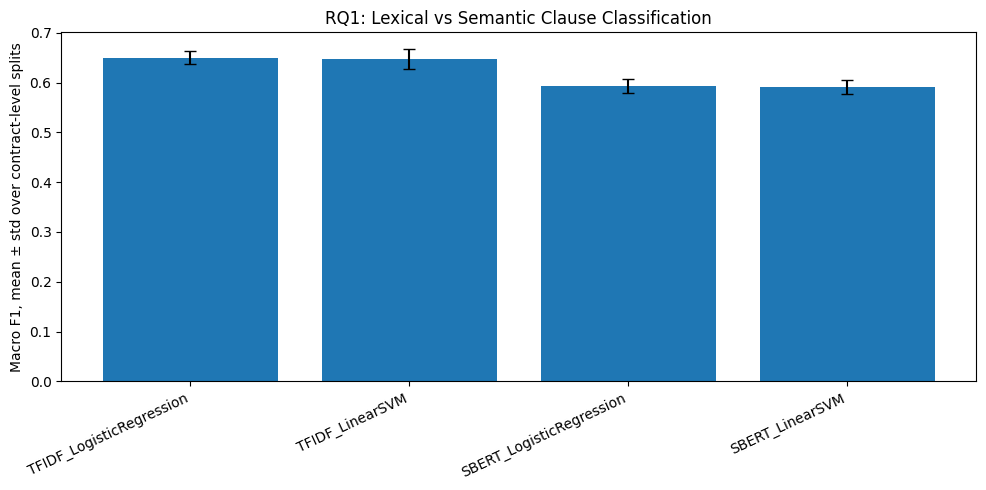

Saved figure: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\figures\rq1_fig1_lexical_vs_semantic_macro_f1.png


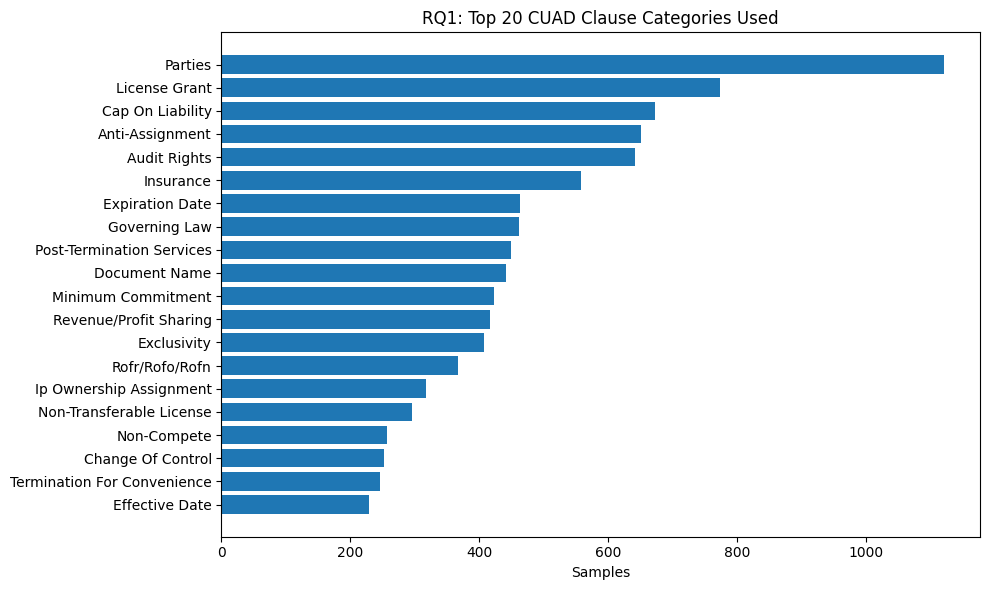

Saved figure: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\figures\rq1_fig2_clause_distribution.png


WindowsPath('c:/Users/a2510/Desktop/new_code/outputs_journal_v2/figures/rq1_fig2_clause_distribution.png')

In [5]:
plt.figure(figsize=(10,5))
plt.bar(summary_df["model"], summary_df["macro_f1_mean"], yerr=summary_df["macro_f1_std"], capsize=4)
plt.ylabel("Macro F1, mean ± std over contract-level splits")
plt.title("RQ1: Lexical vs Semantic Clause Classification")
plt.xticks(rotation=25, ha="right")
savefig("rq1_fig1_lexical_vs_semantic_macro_f1.png")

top_counts = df["label"].value_counts().head(20)
plt.figure(figsize=(10,6))
plt.barh(top_counts.index[::-1], top_counts.values[::-1])
plt.xlabel("Samples")
plt.title("RQ1: Top 20 CUAD Clause Categories Used")
savefig("rq1_fig2_clause_distribution.png")